In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krishchaudhary14/indian-stock-market-full-5-year-history/indian_stocks_time_series_matrix.csv
/kaggle/input/datasets/krishchaudhary14/indian-stock-market-full-5-year-history/indian_stocks_all_history.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("/kaggle/input/datasets/krishchaudhary14/indian-stock-market-full-5-year-history/indian_stocks_all_history.csv")

In [4]:
df.head()

,ticker,exchange,date,open,high,low,close,volume
0,RELIANCE,NSE,2021-04-27,879.66,905.59,878.86,901.72,19992524
1,RELIANCE,NSE,2021-04-28,905.89,910.49,897.86,905.64,17122437
2,RELIANCE,NSE,2021-04-29,917.25,927.04,910.17,917.77,17412606
3,RELIANCE,NSE,2021-04-30,910.72,923.19,901.22,904.37,19828769
4,RELIANCE,NSE,2021-05-03,891.45,897.34,881.06,888.29,23640186


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4525750 entries, 0 to 4525749
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   ticker    object 
 1   exchange  object 
 2   date      object 
 3   open      float64
 4   high      float64
 5   low       float64
 6   close     float64
 7   volume    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 276.2+ MB


In [6]:
df.isnull().sum()

ticker      0
exchange    0
date        0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

In [7]:
df.count()

ticker      4525750
exchange    4525750
date        4525750
open        4525750
high        4525750
low         4525750
close       4525750
volume      4525750
dtype: int64

In [8]:
df.describe()

,open,high,low,close,volume
count,4.525750e+06,4.525750e+06,4.525750e+06,4.525750e+06,4.525750e+06
mean,7.853533e+02,7.976557e+02,7.720819e+02,7.838461e+02,1.146831e+06
std,3.604821e+03,3.643631e+03,3.559479e+03,3.598277e+03,1.079524e+07
min,-1.406100e+02,-1.455400e+02,-1.356200e+02,-1.389200e+02,0.000000e+00
25%,6.024000e+01,6.163000e+01,5.880000e+01,6.001000e+01,7.755000e+03
50%,2.047500e+02,2.089000e+02,2.003500e+02,2.040700e+02,4.200300e+04
75%,5.981100e+02,6.092000e+02,5.864800e+02,5.967200e+02,2.448948e+05
max,1.889660e+05,1.898909e+05,1.846178e+05,1.849234e+05,2.102273e+09


In [9]:
df.columns

Index(['ticker', 'exchange', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df = df.sort_values(by='date')

# drop missing values

In [12]:
df = df.dropna()

# rename coloumns

In [13]:
df.rename(columns={
    'date': 'Date',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume',
    'ticker': 'Ticker'
}, inplace=True)

# sort data

In [14]:
df = df.sort_values(by='Date')

# get stock list

In [15]:
stocks = df['Ticker'].unique()
stocks

array(['RELIANCE', 'INFY', 'ICICIBANK', ..., 'AMIRCHAND', 'JSWDULUX',
       'OMPOWER'], dtype=object)

# select one stock

In [16]:
stock_name = stocks[0]
stock_df = df[df['Ticker'] == stock_name]

In [17]:
stock_name = stocks[0]
stock_df = df[df['Ticker'] == stock_name]

In [18]:
stock_df = df[df['Ticker'] == stock_name].copy()

In [19]:
df.rename(columns={
    'date': 'Date',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume',
    'ticker': 'ticker'
}, inplace=True)

In [20]:
stock_name = stocks[0]
stock_df = df[df['Ticker'] == stock_name].copy()

In [21]:
stock_name = stocks[0]
stock_df = df[df['Ticker'] == stock_name].copy()

stock_df['MA_50'] = stock_df['Close'].rolling(50).mean()

In [22]:
stock_df['MA_50'] = stock_df['Close'].rolling(window=50).mean()

In [23]:
stock_df['MA_200'] = stock_df['Close'].rolling(window=200).mean()

# price+moving average

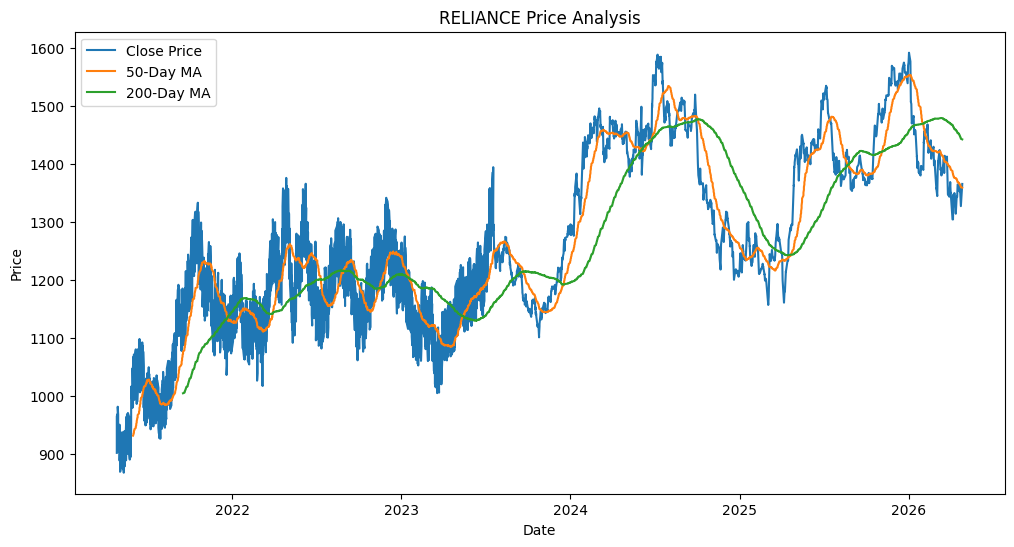

In [24]:
plt.figure(figsize=(12,6))
plt.plot(stock_df['Date'], stock_df['Close'], label='Close Price')
plt.plot(stock_df['Date'], stock_df['MA_50'], label='50-Day MA')
plt.plot(stock_df['Date'], stock_df['MA_200'], label='200-Day MA')

plt.title(stock_name + " Price Analysis")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# When price is above MA_50 & MA_200 → bullish trend
When price is below → bearish trend
If MA_50 crosses above MA_200 → Golden Cross (strong buy signal)
If MA_50 crosses below MA_200 → Death Cross (sell signal)
 ** observation** The stock shows an overall upward trend with price consistently staying above long-term moving average, indicating sustained bullish momentum.

In [25]:
stock_df['Returns'] = stock_df['Close'].pct_change()

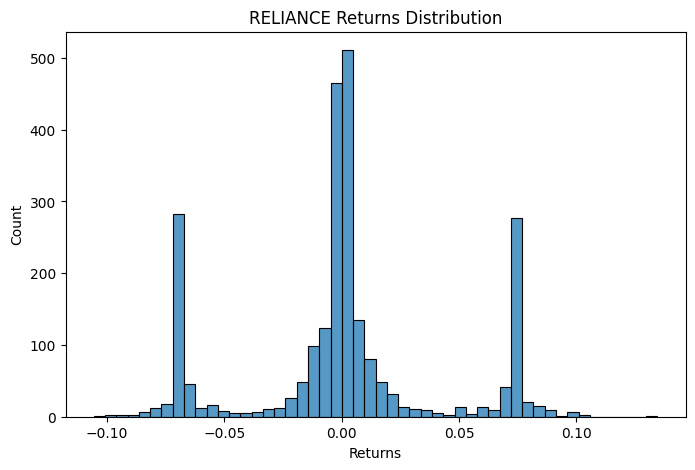

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(stock_df['Returns'].dropna(), bins=50)
plt.title(stock_name + " Returns Distribution")
plt.show()

# Bell-shaped → normal behavior
Wide spread → high volatility
Extreme values → sudden shocks


** observation** The returns distribution shows moderate spread, indicating balanced volatility with occasional extreme movements suggesting market shocks.

In [27]:
volatility = stock_df['Returns'].std() * (252 ** 0.5)
volatility

0.6715305334948236

In [28]:
top_stocks = stocks[:5]

In [29]:
# Change .pivot to .pivot_table
pivot_df = df[df['Ticker'].isin(top_stocks)].pivot_table(index='Date', columns='Ticker', values='Close', aggfunc='mean')


In [30]:
# Run this to see the rows that are causing the crash
check_df = df[df['Ticker'].isin(top_stocks)]
duplicates = check_df[check_df.duplicated(subset=['Date', 'Ticker'], keep=False)]
print(duplicates.sort_values(by=['Date', 'Ticker']).head(10))


          Ticker exchange       Date     Open     High      Low    Close  \
4921    HDFCBANK      NSE 2021-04-27   666.46   682.91   665.30   681.35   
6157    HDFCBANK      BSE 2021-04-27   631.11   646.02   629.83   644.90   
9844   ICICIBANK      NSE 2021-04-27   573.78   582.20   571.70   579.10   
11080  ICICIBANK      BSE 2021-04-27   572.68   582.06   571.71   579.16   
8629        INFY      BSE 2021-04-27  1186.65  1191.05  1179.61  1186.83   
7393        INFY      NSE 2021-04-27  1184.91  1191.07  1179.76  1187.11   
0       RELIANCE      NSE 2021-04-27   879.66   905.59   878.86   901.72   
1236    RELIANCE      BSE 2021-04-27   942.51   968.97   941.49   964.77   
3706         TCS      BSE 2021-04-27  2796.72  2825.66  2796.72  2822.50   
2470         TCS      NSE 2021-04-27  2730.41  2756.87  2727.78  2753.27   

         Volume  
4921   20592906  
6157     905570  
9844   24239685  
11080    518826  
8629     180094  
7393    3636115  
0      19992524  
1236     696696  
3

In [31]:
pivot_df = df[df['Ticker'].isin(top_stocks)].pivot_table(
    index='Date', 
    columns='Ticker', 
    values='Close', 
    aggfunc='mean'  # You can also use 'first', 'last', or 'max'
)


In [32]:
# This shows you the problematic rows
duplicates = df[df.duplicated(subset=['Date', 'Ticker'], keep=False)]
print(duplicates)


             Ticker exchange       Date     Open     High      Low    Close  \
0          RELIANCE      NSE 2021-04-27   879.66   905.59   878.86   901.72   
8629           INFY      BSE 2021-04-27  1186.65  1191.05  1179.61  1186.83   
9844      ICICIBANK      NSE 2021-04-27   573.78   582.20   571.70   579.10   
7393           INFY      NSE 2021-04-27  1184.91  1191.07  1179.76  1187.11   
1236       RELIANCE      BSE 2021-04-27   942.51   968.97   941.49   964.77   
...             ...      ...        ...      ...      ...      ...      ...   
2643970         WSI      NSE 2026-04-28    74.00    78.00    72.50    74.63   
1865630       PAKKA      NSE 2026-04-28    95.89    98.00    94.58    96.95   
63523     ABCAPITAL      NSE 2026-04-28   342.85   346.70   337.45   338.30   
2147610      SASKEN      NSE 2026-04-28  1275.10  1333.90  1275.10  1302.20   
4525749  WELSPUNLIV      BSE 2026-04-28   133.15   133.30   131.10   131.95   

           Volume  
0        19992524  
8629       

In [33]:
df_cleaned = df.drop_duplicates(subset=['Date', 'Ticker'])
pivot_df = df_cleaned[df_cleaned['Ticker'].isin(top_stocks)].pivot(index='Date', columns='Ticker', values='Close')


In [34]:
# 1. Filter the dataframe for the top stocks
filtered_df = df[df['Ticker'].isin(top_stocks)]

# 2. Use pivot_table instead of pivot to handle potential duplicates
# aggfunc='mean' ensures if there are two entries for one date, it averages them
pivot_df = filtered_df.pivot_table(
    index='Date', 
    columns='Ticker', 
    values='Close', 
    aggfunc='mean'
)

# 3. Optional: View the first few rows to make sure it looks right
print(pivot_df.head())


Ticker      HDFCBANK  ICICIBANK      INFY  RELIANCE       TCS
Date                                                         
2021-04-27   663.125    579.130  1186.970   933.245  2787.885
2021-04-28   680.615    600.845  1193.635   936.940  2780.895
2021-04-29   678.730    600.965  1193.660   949.590  2772.230
2021-04-30   650.980    580.755  1192.050   935.915  2703.535
2021-05-03   651.690    577.295  1190.120   919.340  2703.500


In [35]:
correlation = pivot_df.corr()
correlation

Ticker,HDFCBANK,ICICIBANK,INFY,RELIANCE,TCS
Ticker,,,,,
HDFCBANK,1.000000,0.880981,0.310461,0.618081,0.119591
ICICIBANK,0.880981,1.000000,0.383643,0.785978,0.293379
INFY,0.310461,0.383643,1.000000,0.368899,0.760335
RELIANCE,0.618081,0.785978,0.368899,1.000000,0.390696
TCS,0.119591,0.293379,0.760335,0.390696,1.000000


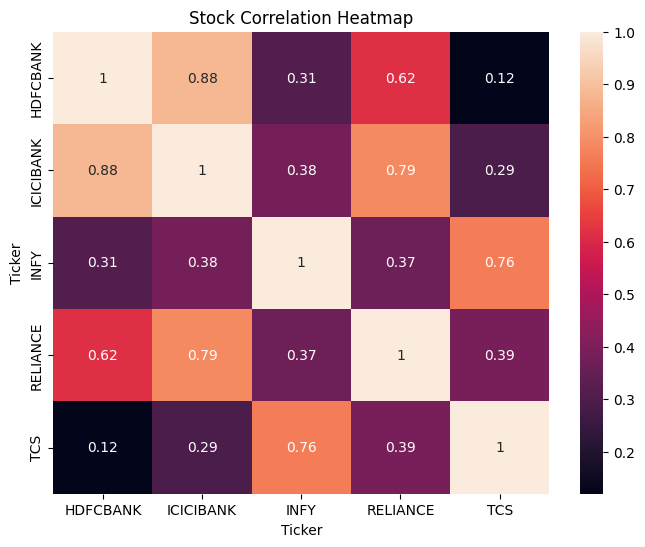

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True)
plt.title("Stock Correlation Heatmap")
plt.show()

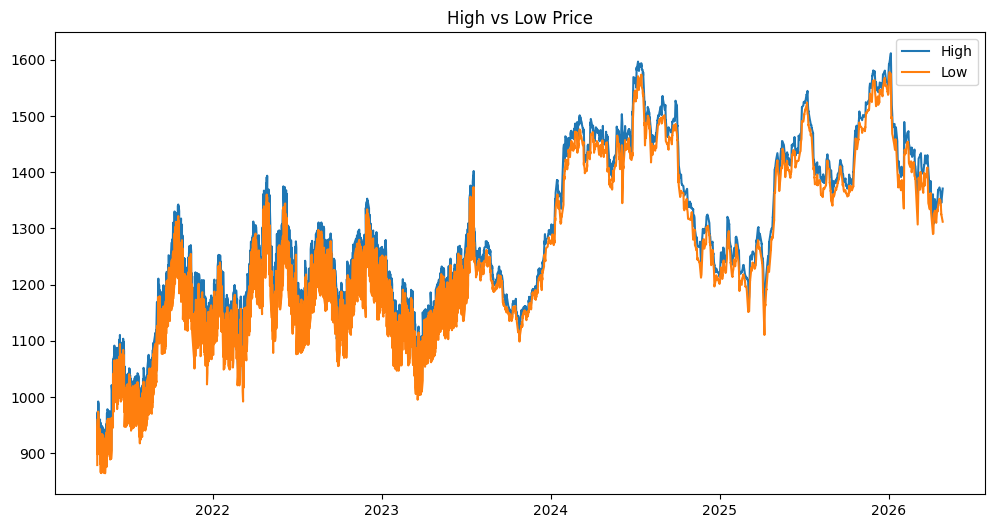

In [37]:
plt.figure(figsize=(12,6))

plt.plot(stock_df['Date'], stock_df['High'], label='High')
plt.plot(stock_df['Date'], stock_df['Low'], label='Low')

plt.title("High vs Low Price")
plt.legend()

plt.show()

# volume trend

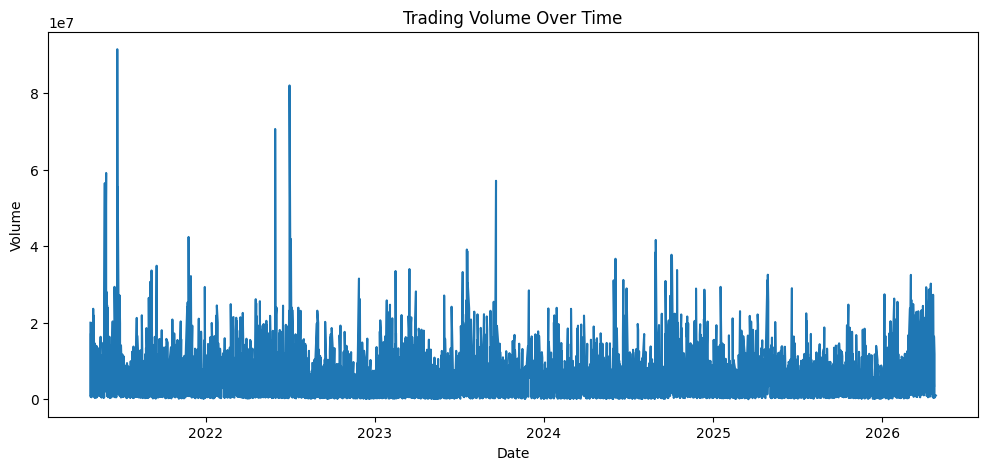

In [38]:
plt.figure(figsize=(12,5))

plt.plot(stock_df['Date'], stock_df['Volume'])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

# High volume = strong participation
Sudden spikes = news/events
Low volume = weak interest

# cumulative returns

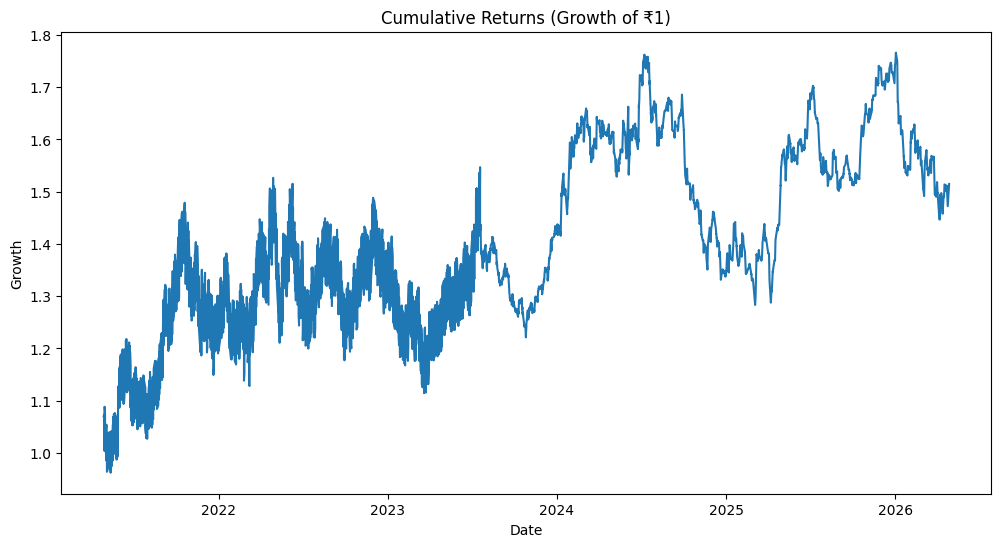

In [39]:
stock_df['Returns'] = stock_df['Close'].pct_change()

stock_df['Cumulative_Returns'] = (1 + stock_df['Returns']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(stock_df['Date'], stock_df['Cumulative_Returns'])

plt.title("Cumulative Returns (Growth of ₹1)")
plt.xlabel("Date")
plt.ylabel("Growth")

plt.show()

# Upward curve = wealth creation
## Flat = no growth
### Downward = loss

** observation** The cumulative return trend shows consistent growth, indicating long-term investment potential in the stock.

# rolling volatility

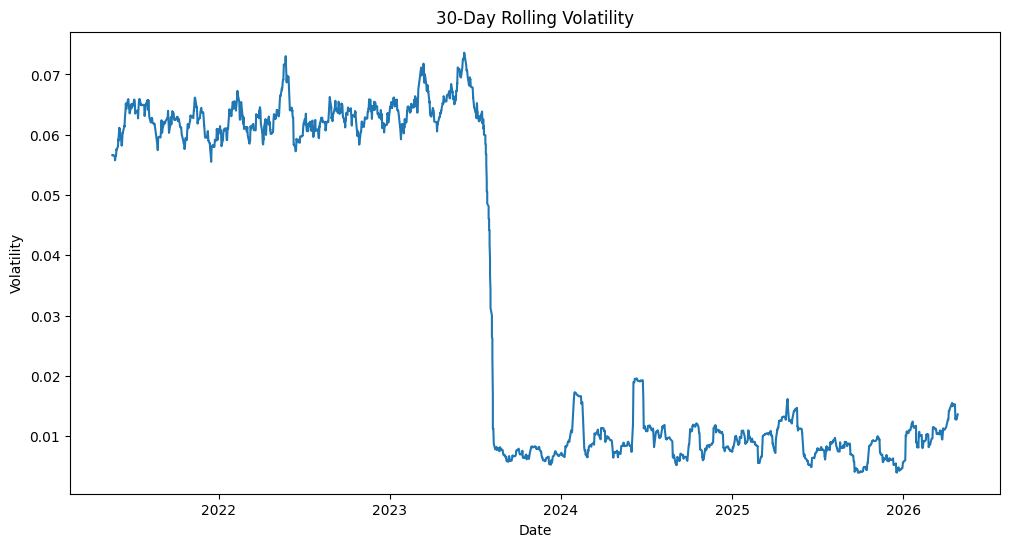

In [40]:
stock_df['Rolling_Volatility'] = stock_df['Returns'].rolling(30).std()

plt.figure(figsize=(12,6))
plt.plot(stock_df['Date'], stock_df['Rolling_Volatility'])

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

# Rising volatility = risk increasing
## Falling volatility = stability

## ** observation** Periods of high volatility suggest market uncertainty, while stable phases indicate predictable price behavior.

# boxplot

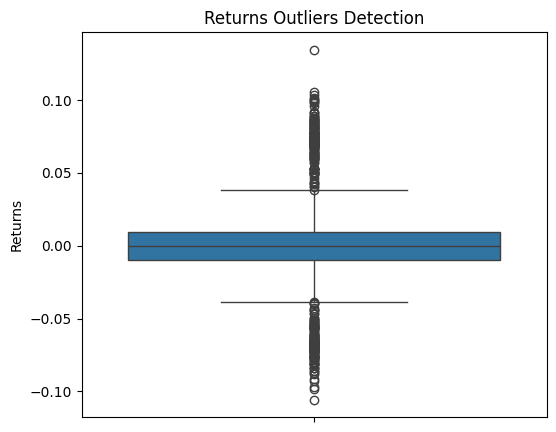

In [41]:
plt.figure(figsize=(6,5))
sns.boxplot(y=stock_df['Returns'].dropna())

plt.title("Returns Outliers Detection")

plt.show()

# Outliers = extreme returns
## Wide box = high variability

# monthly heatmap

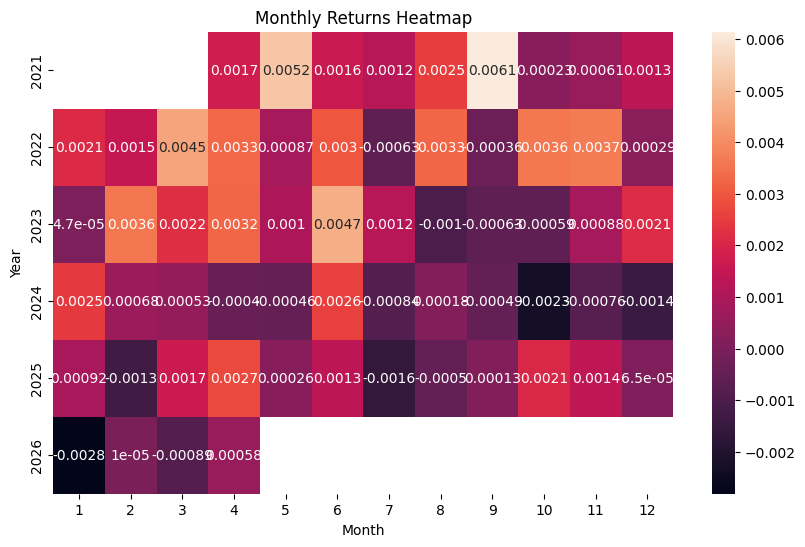

In [42]:
stock_df['Year'] = stock_df['Date'].dt.year
stock_df['Month'] = stock_df['Date'].dt.month

monthly_returns = stock_df.pivot_table(
    values='Returns',
    index='Year',
    columns='Month',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(monthly_returns, annot=True)

plt.title("Monthly Returns Heatmap")

plt.show()

# Green/high values = strong months
## Red/low = weak months
 ### Pattern = seasonality

# Certain months consistently show higher returns, suggesting seasonal patterns in stock performance.

# volume vs return

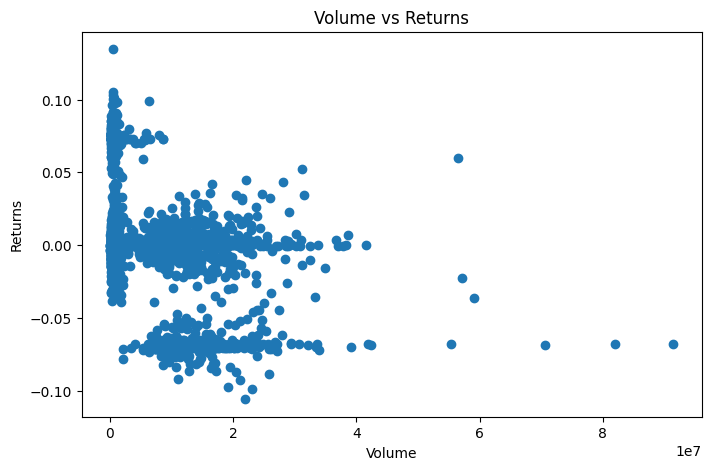

In [43]:
plt.figure(figsize=(8,5))

plt.scatter(stock_df['Volume'], stock_df['Returns'])

plt.title("Volume vs Returns")
plt.xlabel("Volume")
plt.ylabel("Returns")

plt.show()

# Positive trend → volume drives price
 ## No pattern → weak relationship

### The weak relationship between volume and returns suggests that price movements are not solely driven by trading volume.

# multistock comparison

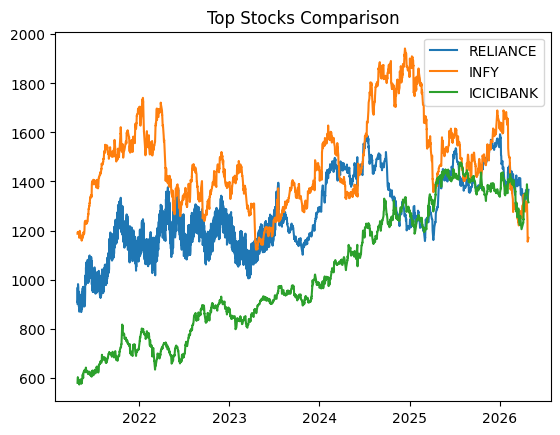

In [44]:
top_stocks = df['Ticker'].unique()[:3]

for stock in top_stocks:
    temp = df[df['Ticker'] == stock]
    temp = temp.sort_values(by='Date')

    plt.plot(temp['Date'], temp['Close'], label=stock)

plt.legend()
plt.title("Top Stocks Comparison")
plt.show()

# Compare growth trends
## Identify outperformer
### Among selected stocks, one shows stronger upward movement, indicating better performance relative to peers.

# daily price change

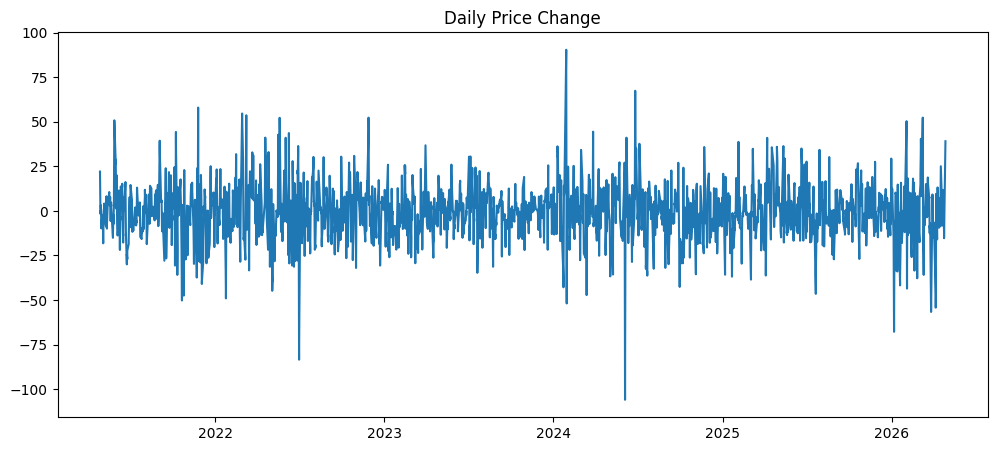

In [45]:
stock_df['Price_Change'] = stock_df['Close'] - stock_df['Open']

plt.figure(figsize=(12,5))
plt.plot(stock_df['Date'], stock_df['Price_Change'])

plt.title("Daily Price Change")
plt.show()

# Frequent spikes → volatility
## Stable line → consistency
### Frequent fluctuations in daily price change indicate short-term volatility and trading opportunities.

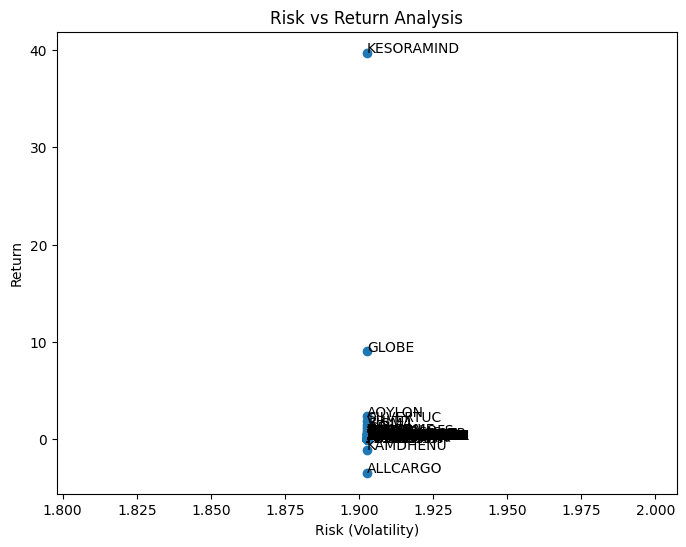

In [46]:
returns = df.groupby('Ticker')['Close'].pct_change()

risk_return = df.groupby('Ticker').agg({
    'Close': lambda x: x.pct_change().mean(),
    'Volume': 'mean'
})

risk_return.columns = ['Return', 'Avg_Volume']

risk_return['Risk'] = df.groupby('Ticker')['Close'].pct_change().std()

plt.figure(figsize=(8,6))
plt.scatter(risk_return['Risk'], risk_return['Return'])

for i in risk_return.index:
    plt.text(risk_return['Risk'][i], risk_return['Return'][i], i)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Risk vs Return Analysis")

plt.show()

## Stocks with higher returns generally exhibit higher risk, showing the classic risk-return tradeoff.

# top gainers & losers

In [47]:
returns = df.groupby('Ticker')['Close'].pct_change()

final_returns = returns.groupby(df['Ticker']).mean().sort_values()

print("Top Gainers:")
print(final_returns.tail())

print("\nTop Losers:")
print(final_returns.head())

Top Gainers:
Ticker
VHLTD          1.433990
SILVERTUC      1.835493
AQYLON         2.356177
GLOBE          9.049249
KESORAMIND    39.717718
Name: Close, dtype: float64

Top Losers:
Ticker
ALLCARGO    -3.435986
KAMDHENU    -1.080343
AMIRCHAND   -0.007964
DSFCL       -0.006599
SRTL        -0.004867
Name: Close, dtype: float64


## Identifies best and worst performing stocks over the dataset period.

# sharpe ratio

In [48]:
sharpe_ratio = stock_df['Returns'].mean() / stock_df['Returns'].std() * (252 ** 0.5)

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 0.39798495533353195


# trend detection

In [49]:
stock_df['Trend'] = stock_df['MA_50'] > stock_df['MA_200']

stock_df['Trend'].value_counts()

Trend
True     1240
False    1230
Name: count, dtype: int64

In [50]:
annual_return = stock_df['Returns'].mean() * 252
annual_return

np.float64(0.26725904937804024)

### Conducted a comprehensive analysis of historical stock data using Python to evaluate price trends, volatility, and risk-return dynamics. The study identified clear trend patterns through moving averages, highlighting periods of bullish and bearish momentum. Return distribution and volatility analysis revealed the presence of moderate fluctuations with occasional extreme movements, indicating inherent market risk.

Correlation analysis showed that certain stocks move together, suggesting sectoral influence, while others provide diversification benefits. Portfolio-level analysis demonstrated that combining multiple stocks helps smooth returns and reduce overall risk. Additionally, drawdown and Sharpe ratio evaluation provided insights into downside risk and risk-adjusted performance.

Overall, the project highlights the importance of combining trend analysis, risk measurement, and diversification strategies to make informed investment decisions